# 2.0 Modelo Base Jerarquico Para Paralajes



Este notebook traduce a codigo una version base del modelo de Leistedt et al. para combinar paralajes y fotometria con un prior jerarquico en el diagrama color-magnitud.



La idea central del articulo es:



- modelar el diagrama color-magnitud como una mezcla discreta de kernels gaussianos con pesos $f_b$;

- tratar la distancia de cada estrella como variable latente;

- usar simultaneamente la verosimilitud de la paralaje y la informacion fotometrica para contraer la incertidumbre en distancia.



En este notebook la implementacion final se hace con PyMC y deja sus resultados guardados para compararlos con NumPyro en notebooks separados.


## Modelo estadístico

Para cada estrella $s$ observamos:

- una paralaje $\hat{\varpi}_s$ con error $\sigma_{\hat{\varpi}, s}$;
- una magnitud aparente $\hat{m}_s$ con error $\sigma_{\hat{m}, s}$;
- un color $\hat{C}_s$ con error $\sigma_{\hat{C}, s}$.

Siguiendo el paper, usamos:

$$
p(\hat{\varpi}_s \mid d_s) = \mathcal{N}\left(\hat{\varpi}_s \mid 1000 / d_s,\ \sigma_{\hat{\varpi}, s}^2\right)
$$

y un prior de color-magnitud como mezcla discreta

$$
p(M_s, C_s \mid \mathbf{f}) = \sum_{b=1}^{B} f_b\, K_b(M_s, C_s), \qquad \sum_b f_b = 1.
$$

Con kernels gaussianos fijos, la contribución fotométrica marginalizada por estrella queda

$$
\log p(\hat{m}_s, \hat{C}_s \mid d_s, \mathbf{f}) = \log \sum_{b=1}^{B} f_b\,
\mathcal{N}\left(\hat{m}_s \mid \mu_{M,b} + 5\log_{10} d_s - 5,\ \sigma_{\hat{m}, s}^2 + \sigma_{M,b}^2\right)
\mathcal{N}\left(\hat{C}_s \mid \mu_{C,b},\ \sigma_{\hat{C}, s}^2 + \sigma_{C,b}^2\right).
$$

La diferencia con la implementación exacta del artículo es computacional: aquí no muestreamos las asignaciones discretas $b_s$, sino que absorbemos esa suma directamente en el logaritmo de la verosimilitud para poder usar NUTS sobre un ejemplo pequeño.


## De $b_s$ explícito a logsumexp

Si no queremos muestrear $b_s$ de forma explícita, podemos marginalizarlo. Para una estrella fija:

$$
p(\hat m_s, \hat C_s \mid d_s, \mathbf f) = \sum_{b=1}^B p(b_s=b \mid \mathbf f)\, p(\hat m_s, \hat C_s \mid d_s, b_s=b).
$$

Como $p(b_s=b \mid \mathbf f)=f_b$, queda:

$$
p(\hat m_s, \hat C_s \mid d_s, \mathbf f) = \sum_{b=1}^B f_b\, p(\hat m_s \mid d_s, b)\, p(\hat C_s \mid b).
$$

Al pasar a logaritmos no puedes distribuir el logaritmo dentro de una suma. Por eso aparece:

$$
\log p(\hat m_s, \hat C_s \mid d_s, \mathbf f) = \log \sum_{b=1}^B \exp\Bigl[\log f_b + \log p(\hat m_s \mid d_s, b) + \log p(\hat C_s \mid b)\Bigr].
$$

Numéricamente eso se evalúa con logsumexp, que es una forma estable de calcular:

$$
\log\sum_b e^{x_b}.
$$

Entonces, conceptualmente:

- con $b_s$ explícito, el modelo es más fácil de leer;
- con logsumexp, estás haciendo exactamente la misma marginalización pero a mano.

## Modelo generativo con $b_s$ explícito

La forma más clara de pensar el modelo es introducir una variable discreta $b_s$ que indica en qué celda del diagrama color-magnitud cae la estrella $s$.

La historia generativa es:

1. Elegir un peso global de mezcla $\mathbf f = (f_1, \dots, f_B)$.
2. Para cada estrella, muestrear una celda

$$
b_s \sim \mathrm{Categorical}(\mathbf f).
$$

3. Condicionado en esa celda, describir magnitud absoluta y color latentes con un kernel gaussiano centrado en la celda:

$$
M_s \mid b_s \sim \mathcal N(\mu_{M,b_s}, \sigma_{M,b_s}^2),
\qquad
C_s \mid b_s \sim \mathcal N(\mu_{C,b_s}, \sigma_{C,b_s}^2).
$$

4. Relacionar esas variables latentes con los observables mediante distancia $d_s$:

$$
\hat \varpi_s \mid d_s \sim \mathcal N\left(1000/d_s, \sigma_{\hat\varpi,s}^2\right),
$$

$$
\hat m_s \mid d_s, M_s \sim \mathcal N\left(M_s + 5\log_{10} d_s - 5, \sigma_{\hat m,s}^2\right),
$$

$$
\hat C_s \mid C_s \sim \mathcal N\left(C_s, \sigma_{\hat C,s}^2\right).
$$

Esta versión es la más fiel al artículo y la más natural para razonar qué papel juega cada variable.

In [1]:
from pathlib import Path
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt


warnings.filterwarnings("ignore", category=UserWarning)

rng = np.random.default_rng(42)
az.style.use("arviz-whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)

In [2]:
ROOT = Path.cwd().resolve().parent
RAW_FILE = ROOT / "data" / "raw" / "GaiaQuery_804d220beb9e16594a86983e84d0cf43.ecsv"


def flux_to_mag_sigma(flux, flux_error):
    snr = np.asarray(flux) / np.asarray(flux_error)
    return 2.5 / np.log(10.0) / snr


def load_simulated_catalog(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, comment="#", sep=r"\s+")
    df.columns = [column.lower() for column in df.columns]

    required = [
        "barycentric_distance",
        "parallax",
        "parallax_error",
        "phot_g_mean_mag",
        "phot_bp_mean_mag",
        "phot_rp_mean_mag",
        "phot_g_mean_flux",
        "phot_g_mean_flux_error",
        "phot_bp_mean_flux",
        "phot_bp_mean_flux_error",
        "phot_rp_mean_flux",
        "phot_rp_mean_flux_error",
        "mag_g",
        "mag_bp",
        "mag_rp",
    ]

    df = df.dropna(subset=required).copy()

    positive = (
        (df["barycentric_distance"] > 0)
        & (df["parallax_error"] > 0)
        & (df["phot_g_mean_flux"] > 0)
        & (df["phot_bp_mean_flux"] > 0)
        & (df["phot_rp_mean_flux"] > 0)
        & (df["phot_g_mean_flux_error"] > 0)
        & (df["phot_bp_mean_flux_error"] > 0)
        & (df["phot_rp_mean_flux_error"] > 0)
    )

    df = df.loc[positive].copy()

    df["color_obs"] = df["phot_bp_mean_mag"] - df["phot_rp_mean_mag"]
    df["sigma_g_mag"] = flux_to_mag_sigma(df["phot_g_mean_flux"], df["phot_g_mean_flux_error"])
    df["sigma_bp_mag"] = flux_to_mag_sigma(df["phot_bp_mean_flux"], df["phot_bp_mean_flux_error"])
    df["sigma_rp_mag"] = flux_to_mag_sigma(df["phot_rp_mean_flux"], df["phot_rp_mean_flux_error"])
    df["sigma_color"] = np.sqrt(df["sigma_bp_mag"] ** 2 + df["sigma_rp_mag"] ** 2)
    df["parallax_snr"] = df["parallax"] / df["parallax_error"]

    return df

catalog = load_simulated_catalog(RAW_FILE)

catalog[[
    "source_id",
    "barycentric_distance",
    "parallax",
    "parallax_error",
    "phot_g_mean_mag",
    "color_obs",
    "sigma_g_mag",
    "sigma_color",
    "parallax_snr",
]].head()

,source_id,barycentric_distance,parallax,parallax_error,phot_g_mean_mag,color_obs,sigma_g_mag,sigma_color,parallax_snr
0,2234570208779960342,3906.3260,-0.609326,0.806744,19.830227,1.774744,0.001042,0.018572,-0.755290
1,2234570208914178050,2812.0623,0.233243,0.460890,19.169176,1.736654,0.000829,0.010985,0.506071
2,2234570208914178053,1883.4900,0.247869,0.507369,19.294239,1.886867,0.000866,0.012249,0.488538
3,2234570208914178056,4419.0810,0.192875,0.274345,18.511656,1.563339,0.000731,0.006476,0.703038
4,2234570208914178057,1425.0234,0.780617,0.109619,17.150677,1.641097,0.000660,0.002276,7.121191


Estrellas disponibles con SNR > 5: 10
Tamano de la muestra usada: 10


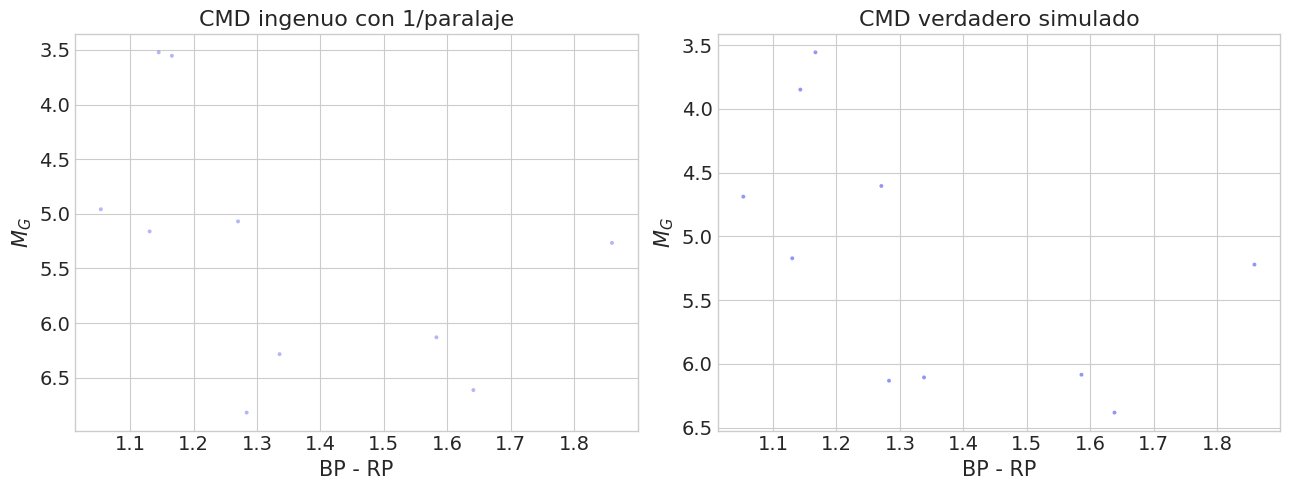

In [3]:
def safe_distance_from_parallax(parallax_mas, floor_mas=0.2):
    clipped = np.clip(np.asarray(parallax_mas), floor_mas, None)
    return 1000.0 / clipped


def absolute_mag_from_distance(apparent_mag, distance_pc):
    return np.asarray(apparent_mag) - 5.0 * np.log10(np.asarray(distance_pc)) + 5.0


def plot_cmd(color, magnitude, *, ax=None, title="CMD observado", alpha=0.35, s=8):
    if ax is None:
        _, ax = plt.subplots()

    mask = np.isfinite(color) & np.isfinite(magnitude)

    ax.scatter(np.asarray(color)[mask], np.asarray(magnitude)[mask], s=s, alpha=alpha, edgecolors="none")
    ax.invert_yaxis()
    ax.set_xlabel("BP - RP")
    ax.set_ylabel(r"$M_G$")
    ax.set_title(title)

    return ax


candidate_pool = catalog.loc[catalog["parallax_snr"] > 5].copy()
sample_size = min(30, len(candidate_pool))
sample = candidate_pool.sample(n=sample_size, random_state=42).sort_values("parallax_snr").reset_index(drop=True)

distance_point = safe_distance_from_parallax(sample["parallax"].to_numpy(), floor_mas=0.05)
sample["abs_mag_point"] = absolute_mag_from_distance(sample["phot_g_mean_mag"], distance_point)
sample["abs_mag_true"] = absolute_mag_from_distance(sample["mag_g"], sample["barycentric_distance"])

print(f"Estrellas disponibles con SNR > 5: {len(candidate_pool)}")
print(f"Tamano de la muestra usada: {sample_size}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_cmd(sample["color_obs"], sample["abs_mag_point"], ax=axes[0], title="CMD ingenuo con 1/paralaje")
plot_cmd(
    sample["mag_bp"] - sample["mag_rp"],
    sample["abs_mag_true"],
    ax=axes[1],
    title="CMD verdadero simulado",
    alpha=0.5,
)

plt.tight_layout()

## Malla fija en el CMD



El paper fija un mosaico de kernels gaussianos en el plano $(M, C)$ y aprende solo sus pesos relativos. Aquí hacemos lo mismo sobre una región construida a partir del CMD ingenuo calculado con $1/\hat{\varpi}$.



La elección es deliberadamente conservadora:



- pocos kernels para que NUTS sea viable en un notebook;

- una muestra pequeña de estrellas;

- prior uniforme por estrella en un intervalo amplio de distancias, centrado en el inverso de la paralaje observada.



Eso no reproduce el Gibbs sampler del artículo, pero sí preserva su estructura probabilística básica.


((7, 5), 35)

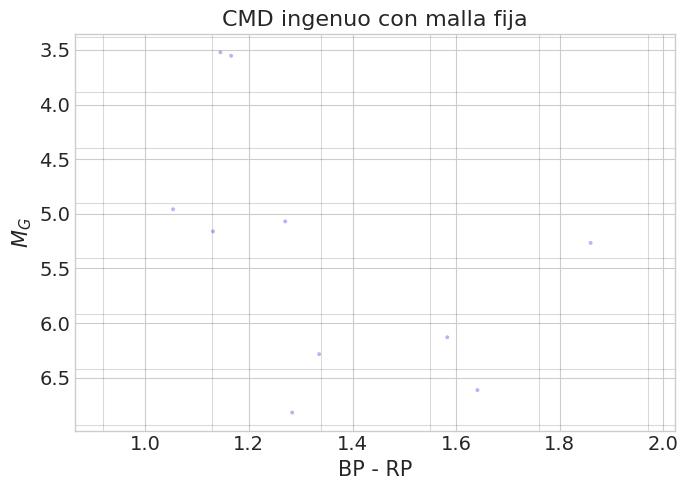

In [4]:
def build_cmd_grid(color_values, abs_mag_values, n_color=5, n_abs_mag=7, padding=0.15):
    color_lo, color_hi = np.quantile(color_values, [0.02, 0.98])
    abs_lo, abs_hi = np.quantile(abs_mag_values, [0.02, 0.98])

    color_edges = np.linspace(color_lo - padding, color_hi + padding, n_color + 1)
    abs_edges = np.linspace(abs_lo - padding, abs_hi + padding, n_abs_mag + 1)

    color_step = float(color_edges[1] - color_edges[0])
    abs_step = float(abs_edges[1] - abs_edges[0])

    color_centers = 0.5 * (color_edges[:-1] + color_edges[1:])
    abs_centers = 0.5 * (abs_edges[:-1] + abs_edges[1:])

    grid_color, grid_abs = np.meshgrid(color_centers, abs_centers, indexing="xy")

    return {
        "mu_color": grid_color.ravel(),
        "mu_abs_mag": grid_abs.ravel(),
        "sigma_color_kernel": np.full(grid_color.size, color_step),
        "sigma_abs_mag_kernel": np.full(grid_abs.size, abs_step),
        "shape": grid_abs.shape,
        "color_edges": color_edges,
        "abs_edges": abs_edges,
    }


def prepare_model_data(df: pd.DataFrame, grid: dict) -> dict:
    parallax = df["parallax"].to_numpy(dtype=float)
    parallax_error = df["parallax_error"].to_numpy(dtype=float)
    m_obs = df["phot_g_mean_mag"].to_numpy(dtype=float)
    sigma_m = df["sigma_g_mag"].to_numpy(dtype=float)
    color_obs = df["color_obs"].to_numpy(dtype=float)
    sigma_color = df["sigma_color"].to_numpy(dtype=float)

    distance_init = np.clip(1000.0 / np.clip(parallax, 0.05, None), 20.0, 6000.0)
    d_lower = np.clip(0.5 * distance_init, 10.0, None)
    d_upper = np.minimum(1.5 * distance_init, 7000.0)
    d_upper = np.maximum(d_upper, d_lower + 25.0)

    return {
        "parallax": parallax,
        "parallax_error": parallax_error,
        "m_obs": m_obs,
        "sigma_m": sigma_m,
        "color_obs": color_obs,
        "sigma_color": sigma_color,
        "distance_init": distance_init,
        "d_lower": d_lower,
        "d_upper": d_upper,
        **grid,
    }


grid = build_cmd_grid(sample["color_obs"], sample["abs_mag_point"], n_color=5, n_abs_mag=7)
model_data = prepare_model_data(sample, grid)

fig, ax = plt.subplots(figsize=(7, 5))
plot_cmd(sample["color_obs"], sample["abs_mag_point"], ax=ax, title="CMD ingenuo con malla fija")

for edge in model_data["color_edges"]:
    ax.axvline(edge, color="black", alpha=0.15, linewidth=0.8)

for edge in model_data["abs_edges"]:
    ax.axhline(edge, color="black", alpha=0.15, linewidth=0.8)

plt.tight_layout()

model_data["shape"], len(model_data["mu_abs_mag"])

## Implementacion Marginalizada En PyMC



Esta es la version practica usada en este notebook.



No es la formulacion mas pedagogica, pero si una forma directa de usar NUTS en PyMC sin introducir variables discretas dentro del sampler.



El modelo computacional usa dos bloques:



1. una verosimilitud gaussiana para la paralaje, con media $1000 / d_s$;

2. una mezcla marginalizada sobre celdas del CMD para magnitud aparente y color.



La cantidad clave por estrella es



$$

\log p(\hat{m}_s, \hat{C}_s \mid d_s, \mathbf{f}) = \operatorname{logsumexp}_b\Bigl[\log f_b + \log p(\hat{m}_s \mid d_s, b) + \log p(\hat{C}_s \mid b)\Bigr].

$$



Eso evita introducir la variable discreta $b_s$ dentro del sampler. En compensacion, cada evaluacion del log posterior necesita recorrer todas las celdas de la malla.


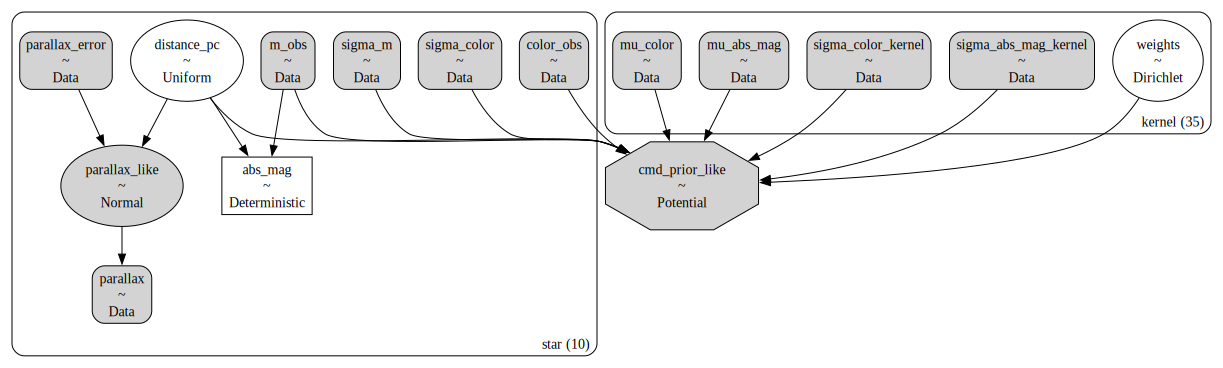

In [5]:
def build_base_cmd_model(data: dict) -> pm.Model:
    coords = {
        "star": np.arange(data["parallax"].size),
        "kernel": np.arange(data["mu_abs_mag"].size),
    }

    with pm.Model(coords=coords) as model:
        parallax = pm.Data("parallax", data["parallax"], dims="star")
        parallax_error = pm.Data("parallax_error", data["parallax_error"], dims="star")
        m_obs = pm.Data("m_obs", data["m_obs"], dims="star")
        sigma_m = pm.Data("sigma_m", data["sigma_m"], dims="star")
        color_obs = pm.Data("color_obs", data["color_obs"], dims="star")
        sigma_color = pm.Data("sigma_color", data["sigma_color"], dims="star")

        mu_abs_mag = pm.Data("mu_abs_mag", data["mu_abs_mag"], dims="kernel")
        mu_color = pm.Data("mu_color", data["mu_color"], dims="kernel")
        sigma_abs_mag_kernel = pm.Data(
            "sigma_abs_mag_kernel",
            data["sigma_abs_mag_kernel"],
            dims="kernel",
        )

        sigma_color_kernel = pm.Data(
            "sigma_color_kernel",
            data["sigma_color_kernel"],
            dims="kernel",
        )

        weights = pm.Dirichlet("weights", a=np.ones(data["mu_abs_mag"].size), dims="kernel")

        distance_pc = pm.Uniform(
            "distance_pc",
            lower=data["d_lower"],
            upper=data["d_upper"],
            initval=data["distance_init"],
            dims="star",
        )

        distance_modulus = 5.0 * pt.log(distance_pc) / np.log(10.0) - 5.0
        pm.Deterministic("abs_mag", m_obs - distance_modulus, dims="star")

        pm.Normal(
            "parallax_like",
            mu=1000.0 / distance_pc,
            sigma=parallax_error,
            observed=parallax,
            dims="star",
        )

        mu_app_mag = mu_abs_mag[None, :] + distance_modulus[:, None]
        sigma_app_mag = pt.sqrt(sigma_m[:, None] ** 2 + sigma_abs_mag_kernel[None, :] ** 2)
        sigma_color_total = pt.sqrt(sigma_color[:, None] ** 2 + sigma_color_kernel[None, :] ** 2)

        logp_mag = pm.logp(pm.Normal.dist(mu=mu_app_mag, sigma=sigma_app_mag), m_obs[:, None])
        logp_color = pm.logp(
            pm.Normal.dist(mu=mu_color[None, :], sigma=sigma_color_total),
            color_obs[:, None],
        )

        log_weights = pt.log(weights)[None, :]

        pm.Potential(
            "cmd_prior_like",
            pt.sum(pt.logsumexp(log_weights + logp_mag + logp_color, axis=1)),
        )

    return model


base_model = build_base_cmd_model(model_data)
pm.model_to_graphviz(base_model)

In [6]:
with base_model:
    idata = pm.sample(
        draws=100,
        tune=100,
        chains=2,
        cores=1,
        target_accept=0.92,
        init="adapt_diag",
        random_seed=42,
        progressbar=True,
        compute_convergence_checks=False,
        nuts_sampler="numpyro",
    )

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

In [7]:
distance_summary = az.summary(idata, var_names=["distance_pc"], round_to=2)
distance_summary.head(10)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
distance_pc[0],2799.38,401.19,2024.72,3511.51,30.95,30.97,161.24,80.90,1.02
distance_pc[1],1647.53,261.42,1324.78,2275.11,23.76,31.48,173.24,66.63,1.04
distance_pc[2],2015.62,282.13,1506.93,2522.29,19.35,17.05,215.22,130.68,1.00
distance_pc[3],1392.53,194.18,1010.06,1706.46,13.70,13.43,221.00,127.93,1.02
distance_pc[4],1345.35,185.15,1055.36,1731.80,12.72,13.05,252.44,105.86,1.02
distance_pc[5],2244.03,323.43,1697.47,2866.33,40.61,68.39,97.86,18.61,1.05
distance_pc[6],1731.36,200.62,1413.67,2161.51,12.35,13.80,280.70,172.02,1.02
distance_pc[7],1566.91,148.90,1299.91,1826.71,11.52,13.46,233.82,95.69,1.00
distance_pc[8],1245.63,97.37,1058.45,1392.17,5.79,7.62,339.60,95.93,0.99
distance_pc[9],921.10,60.08,815.06,1030.33,4.26,3.94,202.31,121.97,1.00


RMSE solo paralaje: 229.5 pc
RMSE modelo jerárquico: 188.0 pc


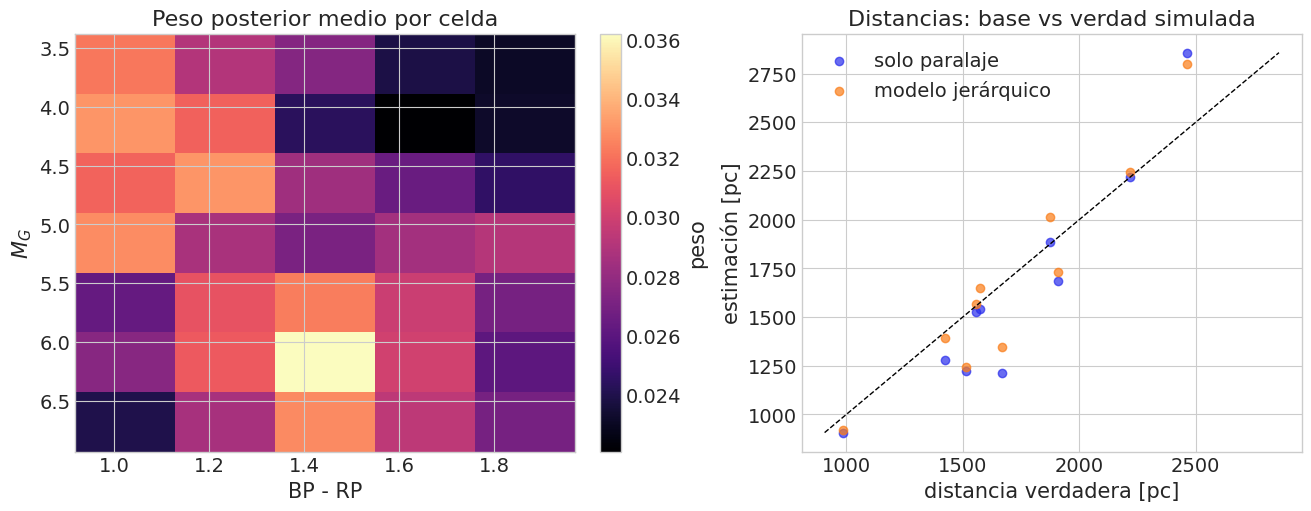

In [8]:
posterior_distance = idata.posterior["distance_pc"].mean(("chain", "draw")).values
posterior_weights = idata.posterior["weights"].mean(("chain", "draw")).values.reshape(model_data["shape"])
parallax_only = model_data["distance_init"]
true_distance = sample["barycentric_distance"].to_numpy()


def rmse(prediction, truth):
    return float(np.sqrt(np.mean((np.asarray(prediction) - np.asarray(truth)) ** 2)))


fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
image = axes[0].imshow(
    posterior_weights,
    aspect="auto",
    origin="lower",
    extent=[
        model_data["color_edges"][0],
        model_data["color_edges"][-1],
        model_data["abs_edges"][0],
        model_data["abs_edges"][-1],
    ],
    cmap="magma",
)

axes[0].invert_yaxis()
axes[0].set_xlabel("BP - RP")
axes[0].set_ylabel(r"$M_G$")
axes[0].set_title("Peso posterior medio por celda")

fig.colorbar(image, ax=axes[0], label="peso")

axes[1].scatter(true_distance, parallax_only, alpha=0.7, label="solo paralaje")
axes[1].scatter(true_distance, posterior_distance, alpha=0.7, label="modelo jerárquico")

limits = [
    min(true_distance.min(), posterior_distance.min(), parallax_only.min()),
    max(true_distance.max(), posterior_distance.max(), parallax_only.max()),
]

axes[1].plot(limits, limits, linestyle="--", color="black", linewidth=1)
axes[1].set_xlabel("distancia verdadera [pc]")
axes[1].set_ylabel("estimación [pc]")
axes[1].set_title("Distancias: base vs verdad simulada")
axes[1].legend()

print(f"RMSE solo paralaje: {rmse(parallax_only, true_distance):.1f} pc")
print(f"RMSE modelo jerárquico: {rmse(posterior_distance, true_distance):.1f} pc")

## Guardar Resultados



Este notebook guarda dos artefactos en models/:



- un archivo NetCDF con las muestras del posterior en formato ArviZ;

- un archivo NPZ con los arreglos necesarios para comparar backends en otro notebook.


In [9]:
RESULTS_DIR = ROOT / "models"
RESULTS_DIR.mkdir(exist_ok=True)


PYMC_IDATA_PATH = RESULTS_DIR / "pymc_base_model.nc"
PYMC_RESULTS_PATH = RESULTS_DIR / "pymc_base_model_results.npz"


idata.to_netcdf(PYMC_IDATA_PATH)

np.savez(
    PYMC_RESULTS_PATH,
    posterior_distance=posterior_distance,
    posterior_weights=posterior_weights,
    true_distance=true_distance,
    parallax_only=parallax_only,
    color_edges=model_data["color_edges"],
    abs_edges=model_data["abs_edges"],
    sample_source_id=sample["source_id"].to_numpy(),
    rmse=rmse(posterior_distance, true_distance),
)


print(f"Posterior PyMC guardado en: {PYMC_IDATA_PATH}")
print(f"Resumen PyMC guardado en: {PYMC_RESULTS_PATH}")

Posterior PyMC guardado en: /var/home/isaac/projects/estimacion-paralajes/models/pymc_base_model.nc
Resumen PyMC guardado en: /var/home/isaac/projects/estimacion-paralajes/models/pymc_base_model_results.npz
